### **1.Consumo di alcol per paese** 
Esegui un’**analisi esplorativa** focalizzata sul **consumo di alcol**.  
Analizza i seguenti aspetti:
* Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

* Calcola la media del consumo di birra, vino, e distillati

* Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`

* Trova il paese con il valore massimo di alcohol_index

* Filtra solo i paesi che consumano più di 100 birre all’anno

Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

Crea un line plot con wine_servings ordinato per paese (usa sort_values)

In [15]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
df

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4
4,Angola,217,57,45,5.9
...,...,...,...,...,...
188,Venezuela,333,100,3,7.7
189,Vietnam,111,2,1,2.0
190,Yemen,6,0,0,0.1
191,Zambia,32,19,4,2.5


In [17]:
df.sort_values(by='total_litres_of_pure_alcohol', ascending=False).head(10)

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
15,Belarus,142,373,42,14.4
98,Lithuania,343,244,56,12.9
3,Andorra,245,138,312,12.4
68,Grenada,199,438,28,11.9
61,France,127,151,370,11.8
45,Czech Republic,361,170,134,11.8
141,Russian Federation,247,326,73,11.5
99,Luxembourg,236,133,271,11.4
155,Slovakia,196,293,116,11.4
81,Ireland,313,118,165,11.4


In [18]:
df[['beer_servings','spirit_servings','wine_servings']].mean() 

beer_servings      106.160622
spirit_servings     80.994819
wine_servings       49.450777
dtype: float64

In [19]:
df['alcohol_index'] = (df['beer_servings'] + df['spirit_servings'] + df['wine_servings'])/3
df['alcohol_index']

0        0.000000
1       91.666667
2       13.000000
3      231.666667
4      106.333333
          ...    
188    145.333333
189     38.000000
190      2.000000
191     18.333333
192     28.666667
Name: alcohol_index, Length: 193, dtype: float64

In [20]:
valore_max = df.loc[df['alcohol_index'].idxmax(), 'country']
valore_max

'Andorra'

In [21]:
df[df['beer_servings']>100]

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,alcohol_index
3,Andorra,245,138,312,12.4,231.666667
4,Angola,217,57,45,5.9,106.333333
5,Antigua & Barbuda,102,128,45,4.9,91.666667
6,Argentina,193,25,221,8.3,146.333333
8,Australia,261,72,212,10.4,181.666667
...,...,...,...,...,...,...
182,United Kingdom,219,126,195,10.4,180.000000
184,USA,249,158,84,8.7,163.666667
185,Uruguay,115,35,220,6.6,123.333333
188,Venezuela,333,100,3,7.7,145.333333


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Belarus'),
  Text(1, 0, 'Lithuania'),
  Text(2, 0, 'Andorra'),
  Text(3, 0, 'Grenada'),
  Text(4, 0, 'France'),
  Text(5, 0, 'Czech Republic'),
  Text(6, 0, 'Russian Federation'),
  Text(7, 0, 'Luxembourg'),
  Text(8, 0, 'Slovakia'),
  Text(9, 0, 'Ireland')])

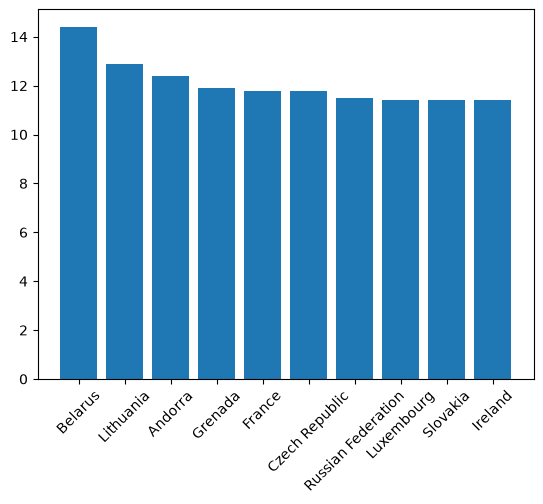

In [22]:
import matplotlib.pyplot as plt
mini_df = df.sort_values(by = 'total_litres_of_pure_alcohol', ascending=False).head(10)
mini_df
country_name = mini_df.country
valori = mini_df.total_litres_of_pure_alcohol
plt.bar(country_name, valori)
plt.xticks(rotation = 45)


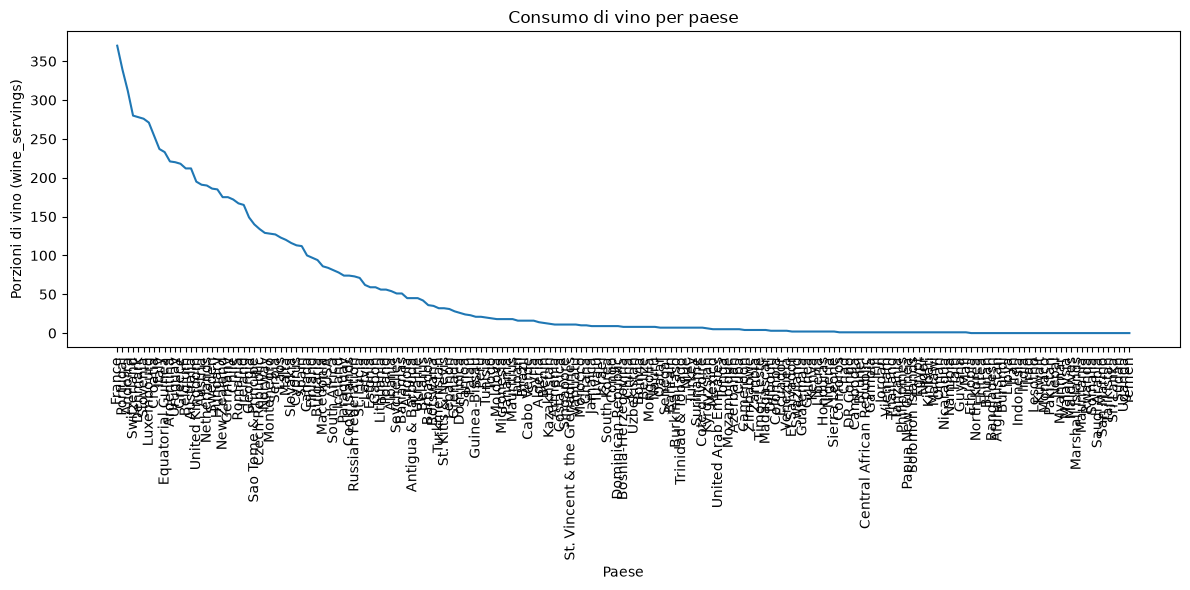

In [25]:
#wine serving oridnato per paese COSA DEVO FARE?
wine_sorted = df.sort_values(by='wine_servings', ascending=False)
plt.figure(figsize=(12, 6))
plt.plot(wine_sorted['country'], wine_sorted['wine_servings'])
plt.title('Consumo di vino per paese')
plt.xlabel('Paese')
plt.ylabel('Porzioni di vino (wine_servings)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### **2.Analisi offerte di lavoro** 

Esegui un’**analisi esplorativa** focalizzata sui **lavori nel campo dei dati in ciascun paese**.  
Analizza i seguenti aspetti per ogni paese:

* Lo **stipendio medio annuale** (`salary_year_avg`)
* Il **numero totale di offerte di lavoro** (job count)
* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)

Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

In [ ]:
%pip install datasets

In [28]:
import pandas as pd
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

c:\Users\mujag\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [29]:
df

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,NaN,NaN,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,"['bash', 'python', 'perl', 'linux', 'unix', 'k...","{'os': ['linux', 'unix'], 'other': ['kubernete..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,"['sas', 'sas', 'sql', 'excel']","{'analyst_tools': ['sas', 'excel'], 'programmi..."
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,NaN,NaN,NaN,Lendlease Corporation,"['powerpoint', 'excel']","{'analyst_tools': ['powerpoint', 'excel']}"
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,"['python', 'go', 'nosql', 'sql', 'mongo', 'she...","{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."


In [30]:
df.groupby('job_country').agg(stipendio_medio = ('salary_year_avg', 'mean'),
                              offerte = ('job_title', 'count'),
                              stipendio_min = ('salary_year_avg', 'min'),
                              stipendio_max = ('salary_year_avg', 'max'))


,stipendio_medio,offerte,stipendio_min,stipendio_max
job_country,,,,
Afghanistan,NaN,16,NaN,NaN
Albania,79472.500000,119,43200.0,157500.0
Algeria,44550.000000,111,44100.0,45000.0
Angola,NaN,11,NaN,NaN
Argentina,105212.343750,8736,45000.0,222000.0
...,...,...,...,...
Venezuela,NaN,69,NaN,NaN
Vietnam,90927.236364,2414,28000.0,200000.0
Yemen,NaN,10,NaN,NaN


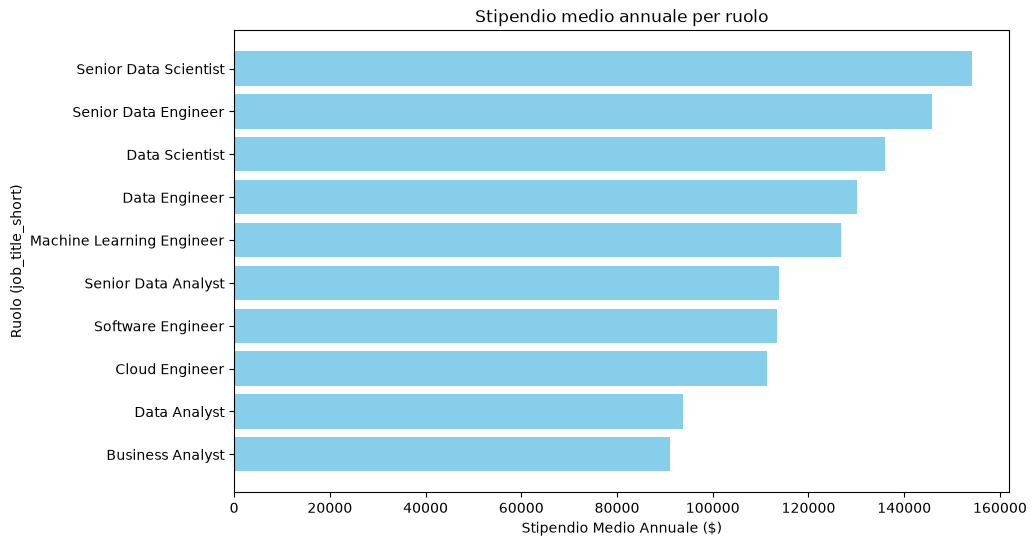

In [33]:
import matplotlib.pyplot as plt
df_stipendi = df.groupby('job_title_short')['salary_year_avg'].mean().sort_values(ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(df_stipendi.index, df_stipendi.values, color='skyblue')
plt.title('Stipendio medio annuale per ruolo')
plt.xlabel('Stipendio Medio Annuale ($)')
plt.ylabel('Ruolo (job_title_short)')
plt.show()

### **3. Analisi vendite (dataset tips)**

Esegui un’**analisi esplorativa** focalizzata sulle **vendite giornaliere**.  
Analizza i seguenti aspetti per ogni giorno (`day`):

* Il **conto medio** (`total_bill`)
* Il **numero totale di osservazioni** (conteggio delle righe)
* Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)

* Crea una nuova colonna `conto_per_persona` che sia:  
  `total_bill / size`

* Trova il giorno con il **conto medio più alto**

Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
Ordina i dati dal valore più alto al più basso.  
Aggiungi titolo ed etichette agli assi.

In [35]:
import pandas as pd
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [36]:
df.shape

(244, 7)

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    str    
 3   smoker      244 non-null    str    
 4   day         244 non-null    str    
 5   time        244 non-null    str    
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 17.3 KB


In [38]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [39]:
df.groupby('day').agg(conto_medio = ('total_bill', 'mean'),
                      osservazioni = ('total_bill', 'count'),
                      valore_min = ('total_bill', 'min'),
                      valore_max = ('total_bill', 'max'))

,conto_medio,osservazioni,valore_min,valore_max
day,,,,
Fri,17.151579,19,5.75,40.17
Sat,20.441379,87,3.07,50.81
Sun,21.410000,76,7.25,48.17
Thur,17.682742,62,7.51,43.11


In [40]:
df['conto_per_persona'] = df['total_bill']/df['size']

In [42]:
conto_medio_per_giorno = df.groupby('day')['total_bill'].mean()
giorno_max = conto_medio_per_giorno.idxmax()
valore_max = conto_medio_per_giorno.max()
valore_max

np.float64(21.41)

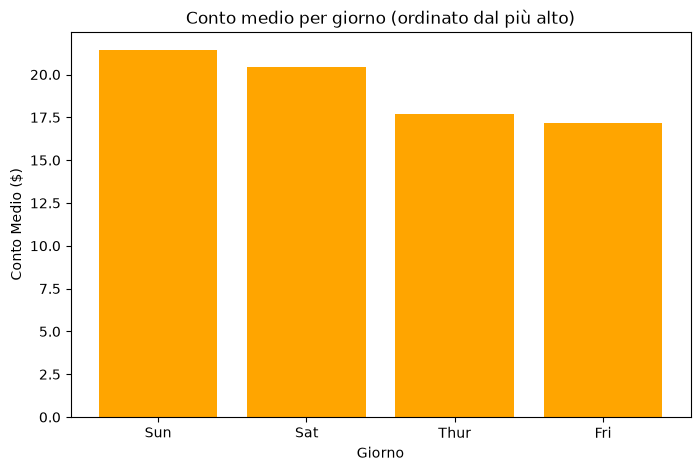

In [43]:
import matplotlib.pyplot as plt
conto_ordinato = conto_medio_per_giorno.sort_values(ascending=False)
plt.figure(figsize=(8, 5))
plt.bar(conto_ordinato.index, conto_ordinato.values, color='orange')
plt.title('Conto medio per giorno (ordinato dal più alto)')
plt.xlabel('Giorno')
plt.ylabel('Conto Medio ($)')
plt.xticks(rotation=0)
plt.show()